In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Dataset: Brain Mass vs Body Mass (Vertebrates) 
FROM GIVEN DATASET


Loaded Dataset 17: Brain Mass vs Body Mass (Vertebrates)
  Data points: 13
  Range: 0.02 to 3000.00


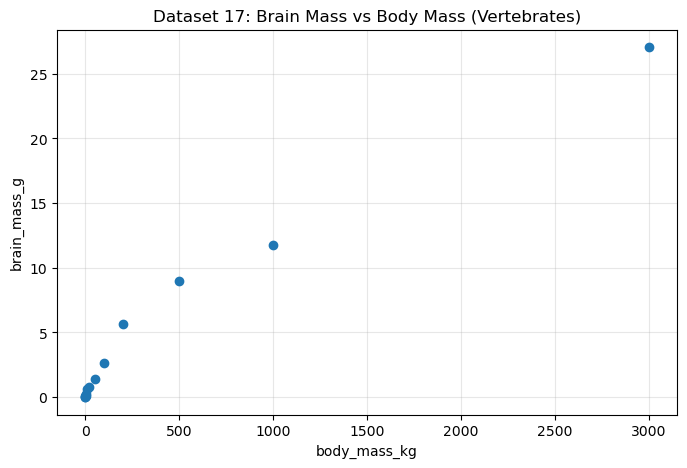

In [2]:
# Dataset 17: Brain Mass vs Body Mass (Vertebrates) FROM GIVEN DATASET
t_data = np.array([0.02, 0.1, 0.5, 1, 5, 10, 20, 50, 100, 200, 500, 1000, 3000])
y_data = np.array([0.007201, 0.01788, 0.06587, 0.1199, 0.2821, 0.6413, 0.8199, 1.429, 2.661, 5.616, 8.968, 11.73, 27.05])

print(f"Loaded Dataset 17: Brain Mass vs Body Mass (Vertebrates)")
print(f"  Data points: {len(t_data)}")
print(f"  Range: {t_data.min():.2f} to {t_data.max():.2f}")

# Quick plot
plt.figure(figsize=(8, 5))
plt.plot(t_data, y_data, 'o', markersize=6)
plt.xlabel('body_mass_kg')
plt.ylabel('brain_mass_g')
plt.title('Dataset 17: Brain Mass vs Body Mass (Vertebrates)')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Define power law model
def power_law(x, a, b):
    return a * x**b
# Calculate data-driven initial guesses
log_x = np.log(t_data)
log_y = np.log(y_data)
coeffs = np.polyfit(log_x, log_y, 1)
b_initial = coeffs[0]  
a_initial = np.exp(coeffs[1])  
# Fit using nonlinear regression
params, covariance = curve_fit(power_law, t_data, y_data, p0=[a_initial, b_initial])
a, b = params
# I used p0 based on the log linear fit to get a better starting point for the nonlinear regression.

print("Nonlinear Regression Results:")
print(f"  a = {a:.3f} ± {np.sqrt(covariance[0, 0]):.3f}")
print(f"  b = {b:.3f} ± {np.sqrt(covariance[1, 1]):.3f}")
print(f"\nModel: Brain Mass = {a:.3f} × (Body Mass)^{b:.3f}")

Nonlinear Regression Results:
  a = 0.138 ± 0.025
  b = 0.658 ± 0.024

Model: Brain Mass = 0.138 × (Body Mass)^0.658


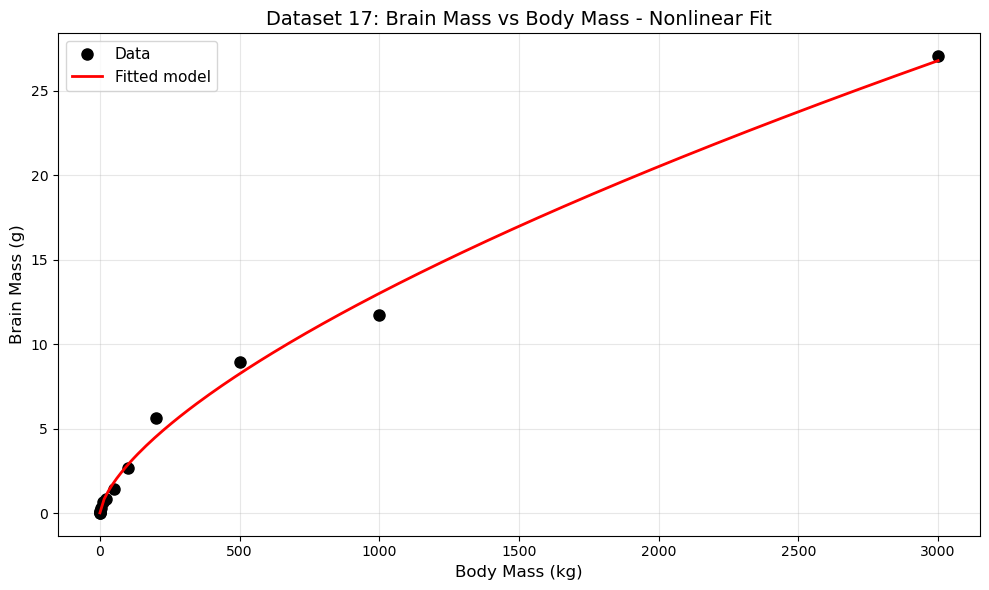

In [4]:
# Create smooth curve for plotting
x_smooth = np.linspace(t_data.min(), t_data.max(), 200)
y_fit = power_law(x_smooth, a, b)

# Plot the data and fitted curve
plt.figure(figsize=(10, 6))
plt.plot(t_data, y_data,'o', markersize=8, label='Data', color='black')
plt.plot(x_smooth, y_fit, '-', linewidth=2, label='Fitted model', color='red')

plt.xlabel('Body Mass (kg)', fontsize=12)
plt.ylabel('Brain Mass (g)', fontsize=12)
plt.title('Dataset 17: Brain Mass vs Body Mass - Nonlinear Fit', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

R² of the fit: 0.9949


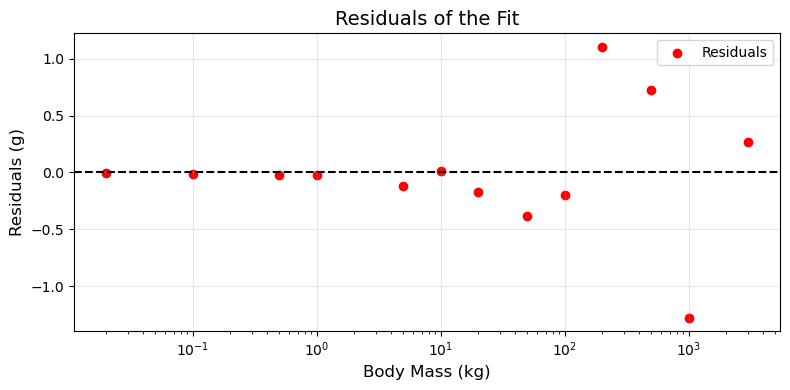


Residual Analysis:
Mean residual:     -0.01
Std dev residual:  0.53
Max |residual|:    1.28


In [5]:
#Calculating the R^2 value
R_2 = 1 - np.sum((y_data - power_law(t_data, a, b))**2) / np.sum((y_data - np.mean(y_data))**2)
print(f"R² of the fit: {R_2:.4f}")

#Calcuating the residuals
residuals = y_data - power_law(t_data, a, b)
plt.figure(figsize=(8, 4))
plt.scatter(t_data, residuals, color='red', label='Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.xscale('log')
plt.xlabel('Body Mass (kg)', fontsize=12)
plt.ylabel('Residuals (g)', fontsize=12)
plt.title('Residuals of the Fit', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Calculating the mean and std dev of Residuals

print("\nResidual Analysis:")
print(f"Mean residual:     {np.mean(residuals):.2f}")
print(f"Std dev residual:  {np.std(residuals):.2f}")
print(f"Max |residual|:    {np.max(np.abs(residuals)):.2f}")

1. After using visual reasoning to view the power model used it looks extremely accurate based on the dataset where it passes through nearly all points of the data cloud with bounds of the min and max of t_data on the x-axis. Then finally using t_smooth to plot all the data points smoothly of the model I used.

In [6]:
# Predict brain mass for a given body mass using the fitted power-law model
body_mass_kg = 99634000  # Godzilla body mass (kg)
predicted_brain_g = power_law(body_mass_kg, a, b)

print(f"Body mass (kg): {body_mass_kg:,}")
print(f"Predicted brain mass (g): {predicted_brain_g:,.2f}")
print(f"Predicted brain mass (kg): {predicted_brain_g/1000:,.2f}")
print(f"Predicted brain mass (tons): {predicted_brain_g/1e6:,.2f}")
print(f'The average human brain mass is about 1.4 kg, so Godzilla\'s predicted brain mass is approximately {predicted_brain_g/1000/1.4:.2f} times that of a human brain.')

Body mass (kg): 99,634,000
Predicted brain mass (g): 25,186.98
Predicted brain mass (kg): 25.19
Predicted brain mass (tons): 0.03
The average human brain mass is about 1.4 kg, so Godzilla's predicted brain mass is approximately 17.99 times that of a human brain.
